# 05 — Velocity-centered ζ dipole on real MDPL2 halos

**Exploratory twin of `scripts/plot_velocity_centered_dipole.py`.** Both this
notebook and that script call the same stage functions from
`dvcorr.pipeline.velocity_centered` — the single source of truth for this
pipeline (CLAUDE.md: notebooks are exploration only, "diagnostics that import
the real modules, never reimplement them"). Every code cell below just calls
one of those stage functions — `load_and_carve`, `draw_candidates`,
`run_estimator`, `global_number_density`, `normalize_result`, `make_figure`
— in sequence, so what you see here is exactly what
`python -m scripts.plot_velocity_centered_dipole` produces, one stage at a
time.

This measures the **velocity-centered** statistic ζ (Nusser 2017 eq. 23-24),
the mirror image of notebook 04's group-centered ξ_Tu: here a VELOCITY object
sits at the center and DENSITY tracers are counted in shells around it. Per
`dvcorr.conventions.nusser_multipole_sign`, ζ_ℓ = (−1)^ℓ ξ_Tu,ℓ — monopoles agree, but the
dipole flips sign. **Coherent infall therefore gives a POSITIVE ζ₁** here,
the opposite of notebook 04's negative ξ_Tu,1 (CLAUDE.md hard rule 2 states
the group-centered sign; this is its velocity-centered mirror, made explicit in
`dvcorr/estimators/shell_dipole.py`'s module docstring and pinned by the joint sign
gate in `tests/test_velocity_centered_dipole.py`).

In [ ]:
%matplotlib inline

import numpy as np

from dvcorr import conventions
from dvcorr.config import PathsConfig
from dvcorr.pipeline.velocity_centered import (
    RunConfig,
    load_and_carve,
    draw_candidates,
    run_estimator,
    global_number_density,
    normalize_result,
    make_figure,
)

print("observer (box center):", conventions.OBSERVER_POSITION)
print("BOX_SIZE            :", conventions.BOX_SIZE, " h^-1 Mpc")
print("MAX_ANALYSIS_RADIUS :", conventions.MAX_ANALYSIS_RADIUS, " h^-1 Mpc")

## Parameters

`RunConfig` holds every tunable number (CLAUDE.md hard rule 4), including the
radial shell binning as a composed `dvcorr.config.ShellConfig` (`cfg.shells`).
Its default `min_radius` equals `radii_step`, not 0 — candidates are
subsampled from the tracer array itself, so every candidate is its own
tracer at r = 0, and excluding that self-pair bin keeps it out of the
monopole diagnostic panel plotted below.

In [ ]:
cfg = RunConfig()
paths = PathsConfig()
observer = np.asarray(conventions.OBSERVER_POSITION, dtype=float)

print(cfg)
print("shell_edges:", cfg.shells.shell_edges)

## 1 — Load and carve

`load_and_carve` loads only `dvcorr.conventions.POSITION_COLUMNS + dvcorr.conventions.VELOCITY_COLUMNS`
from the ~4M-row MDPL2 catalog, then keeps halos within
`cfg.sub_volume_radius` of the observer. As in notebook 04, plain Euclidean
distance IS the minimum image here — the sub-volume sits well inside the
box, clear of the periodic faces — so no wrapping is needed.

In [3]:
pos, vel = load_and_carve(cfg, paths)

loading /home/ofeke2000/Cross-correlating-Tempel-SDSS-groups-with-Cosmicflows-4-peculiar-velocities/data/mdpl2_rockstar_125_pid-1_mvir12.csv (columns: ['x', 'y', 'z', 'vx', 'vy', 'vz']) ...


loaded 4093751 halos


carved 464764 of 4093751 halos within sub_volume_radius = 300.0 h^-1 Mpc (11.35%)


## 2 — Draw candidate centers

A seeded subsample of the carved halos, as CANDIDATE velocity-object
centers. Not every candidate survives: `run_estimator` (next cell) applies
`core_center_mask` internally, keeping only candidates whose full shell (out
to `r_max`) fits inside the carved sub-volume — the core cut notebook 04's
group-centered run did not have.

In [4]:
s_candidates, v_candidates = draw_candidates(cfg, pos, vel)
print("candidate centers:", s_candidates.shape[0])

candidate centers: 4000


## 3 — Run the estimator

Tracers = ALL carved halos. `run_estimator` prints `n_candidates` vs.
`n_centers` — with the default `sub_volume_radius = 300` and
`core_margin = r_max = 60`, expect roughly half the candidates to survive
(a (240/300)³ ≈ 51% volume cut). That loss is meant to be visible here, not
silent.

In [5]:
s_tracers = pos
result = run_estimator(cfg, s_candidates, v_candidates, s_tracers, observer)

n_candidates = 4000, n_centers = 2031 (50.8% survive the core cut)


## 4 — Normalize + shuffle null

`global_number_density` gives n̄ over the sub-volume; `normalize_result`
turns the raw `result` + n̄ into ζ̂₁(r), its SEM band, the velocity-shuffle
null (a seeded permutation of `per_center_u` recombined with
`per_center_amplitude` — no second estimator pass), and the normalized
monopole ζ̂₀(r).

In [6]:
n_bar = global_number_density(pos.shape[0], cfg.sub_volume_radius)
normalized = normalize_result(result, n_bar, cfg.shuffle_seed)

print("r_cen        :", np.round(result.shell_centers, 1))
print("zeta_hat     :", np.round(normalized.zeta_hat, 2))
print("SEM          :", np.round(normalized.sem, 2))
print("shuffle null :", np.round(normalized.zeta_hat_shuffle, 2))
print("monopole     :", np.round(normalized.monopole_norm, 2))

r_cen        : [ 7.5 12.5 17.5 22.5 27.5 32.5 37.5 42.5 47.5 52.5 57.5]
zeta_hat     : [144.18 104.71  84.35  65.07  54.1   44.3   38.71  30.76  26.7   23.56
  19.47]
SEM          : [10.29  6.63  4.77  3.65  3.24  2.55  2.31  2.07  1.83  1.53  1.41]
shuffle null : [-3.68  2.49  0.37  0.92 -5.29 -3.02 -0.75 -2.33 -0.77  0.29  1.03]
monopole     : [-19.85 -11.77  -9.48  -7.09  -4.61  -3.68  -3.01  -2.53  -2.34  -2.55
  -1.99]


## 5 — Plot

What to look for:

- **ζ̂₁ positive, largest at small r** ⇒ coherent infall, under the
  velocity-centered sign convention (the opposite of notebook 04's negative
  ξ_Tu,1 — see the intro cell). A NEGATIVE ζ̂₁ here would be the orientation
  bug, not a result.
- **monopole panel (ζ̂₀) near zero** ⇒ the trust diagnostic: shells are
  angularly complete and there is no residual bulk-motion / truncation
  leakage biasing the dipole above it (CLAUDE.md hard rule 6).
- **shuffle null flat, consistent with zero** ⇒ the signal is the
  velocity–density correlation, not a geometric artifact.

`make_figure` returns the `Figure` (it does not save, and never calls
`plt.show`); this cell saves the PNG using the SAME path logic as `main()`,
then displays the figure inline.

wrote /home/ofeke2000/Cross-correlating-Tempel-SDSS-groups-with-Cosmicflows-4-peculiar-velocities/output/velocity_centered_dipole.png


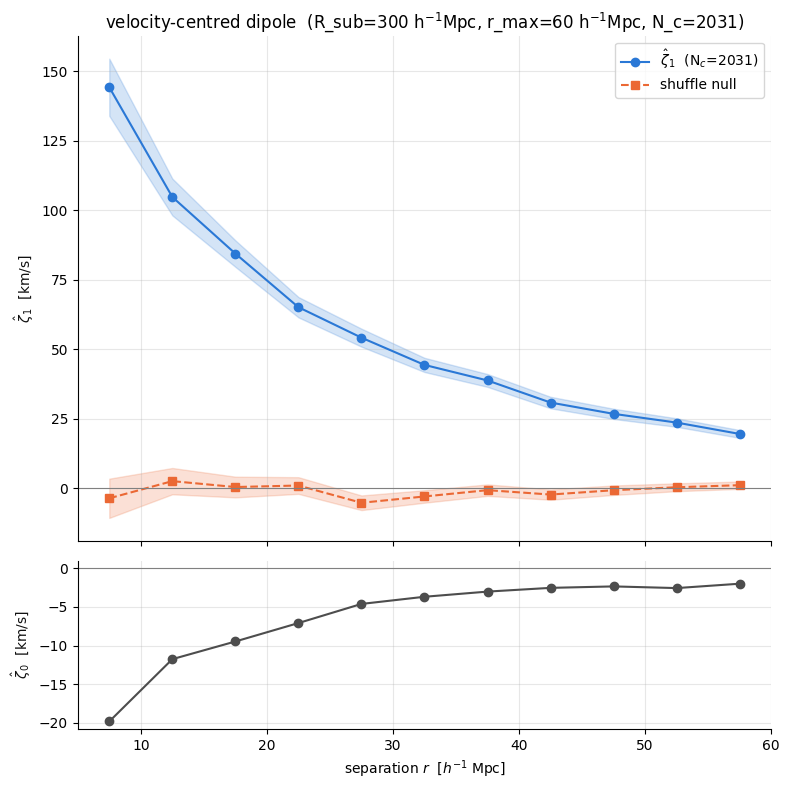

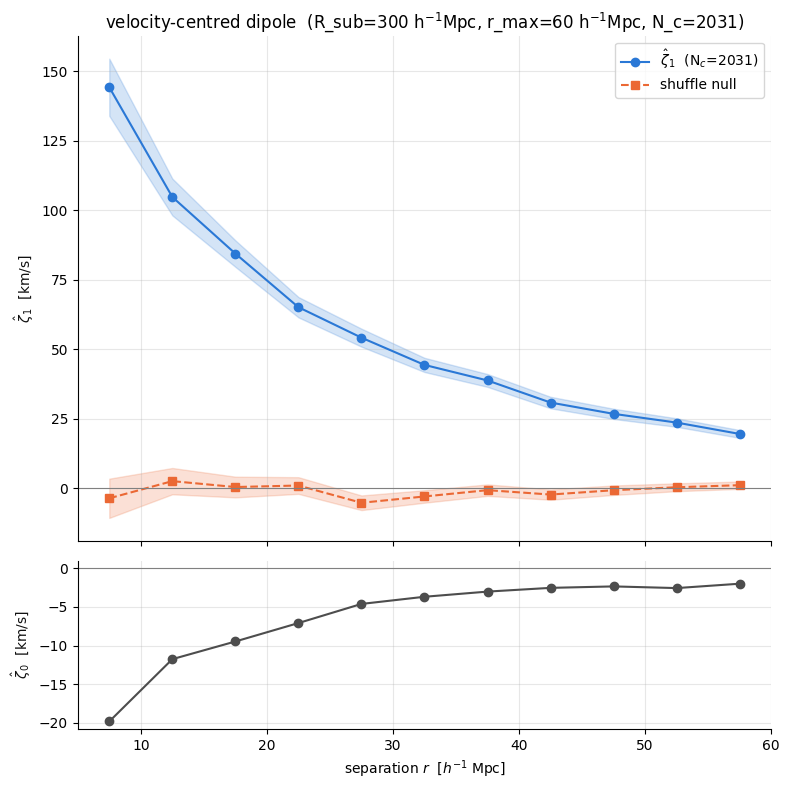

In [7]:
fig = make_figure(cfg, result, normalized)

paths.ensure_output_dir()
out_path = paths.output_dir / cfg.output_name
fig.savefig(out_path, dpi=cfg.dpi, bbox_inches="tight")
print(f"wrote {out_path}")

fig